In [1]:
import subprocess
from pathlib import Path
import numpy as np
%matplotlib ipympl
import seaborn as sns
import matplotlib.pyplot as plt
from buttons import *
from ipywidgets import interact
from IPython.display import HTML, display

FLOWPATEXE = "external/Flowpat.exe"

def create_transition_lines_input_file(ρ_L, ρ_G, μ_L, μ_G, σ, D, θ, k_s, interface, out_path):
    mode = 1
    with open(out_path / "Input.txt", "w") as f:
        f.write(f"{mode}          Mode 1-Transition Lines, 2-FlowPattern Prediction\n")
        f.write(f"{      ρ_L:<10.5g} Liquid Density [Kg/m^3]\n")
        f.write(f"{      μ_L:<10.5g} Liquid Viscosity [Pa s]\n")
        f.write(f"{        σ:<10.5g} Surface Tension [N/m]\n")
        f.write(f"{      ρ_G:<10.5g} Gas Density [Kg/m^3]\n")
        f.write(f"{      μ_G:<10.5g} Gas Viscosity [Pa s]\n")
        f.write(f"{        D:<10.5g} Pipe Diameter [m]\n")
        f.write(f"{        θ:<10.5g} Pipe inclination  Angle [deg]\n")
        f.write(f"{      k_s:<10.5g} Pipe Roughness [m]\n")
        f.write(f"{interface}          Interface 1-Smooth, 2-Wavy\n")

def create_flow_pattern_input_file(us_L, us_G, ρ_L, ρ_G, μ_L, μ_G, σ, D, θ, k_s, out_path):
    mode = 2
    with open(out_path / "Input.txt", "w") as f:
        f.write(f"{mode}          Mode 1-Transition Lines, 2-FlowPattern Prediction\n")
        f.write(f"{us_L:<10.5g} ")
        f.write(f"{us_G:<10.5g} ")
        f.write(f"{ ρ_L:<10.5g} ")
        f.write(f"{ μ_L:<10.5g} ")
        f.write(f"{ ρ_G:<10.5g} ")
        f.write(f"{ μ_G:<10.5g} ")
        f.write(f"{   σ:<10.5g} ")
        f.write(f"{   D:<10.5g} ")
        f.write(f"{   θ:<10.5g} ")
        f.write(f"{ k_s:<10.5g} ")

def create_out_path():
    out_path = Path("out")
    out_path.mkdir(exist_ok=True)
    return out_path

def run_flowpat(out_path):
    subprocess.call([FLOWPATEXE], cwd=out_path)
    return np.loadtxt(out_path / "Output.txt")

def calculate_transition_lines(ρ_L, ρ_G, μ_L, μ_G, σ, D, θ, k_s, interface):
    out_path = create_out_path()
    create_transition_lines_input_file(ρ_L, ρ_G, μ_L, μ_G, σ, D, θ, k_s, interface, out_path)
    return run_flowpat(out_path)

flow_pattern_name = {
    1: ("SS", "Stratified"),
    2: ("SW", "Stratified Wavy"),
    3: ("A",  "Annular"),
    4: ("DB", "Dispersed Bubble"),
    5: ("B", "Bubbly"),
    6: ("SL", "Slug"),
}
def calculate_flow_pattern(us_L, us_G, ρ_L, ρ_G, μ_L, μ_G, σ, D, θ, k_s):
    out_path = create_out_path()
    create_flow_pattern_input_file(us_L, us_G, ρ_L, ρ_G, μ_L, μ_G, σ, D, θ, k_s, out_path)
    results = run_flowpat(out_path)

    error_code = results[-1] if len(results) > 0 else -999
    
    if error_code > 0:
        return None

    flow_pattern_id = int(results[-2])
    return flow_pattern_name[flow_pattern_id]

<>:46: SyntaxWarning: invalid escape sequence '\;'
<>:47: SyntaxWarning: invalid escape sequence '\;'
<>:46: SyntaxWarning: invalid escape sequence '\;'
<>:47: SyntaxWarning: invalid escape sequence '\;'
C:\Users\byy\AppData\Local\Temp\ipykernel_11652\742255168.py:46: SyntaxWarning: invalid escape sequence '\;'
  ax.set_xlabel('$U_{SG}\;[m/s]$', labelpad=10)
C:\Users\byy\AppData\Local\Temp\ipykernel_11652\742255168.py:47: SyntaxWarning: invalid escape sequence '\;'
  ax.set_ylabel('$U_{SL}\;[m/s]$', labelpad=10)


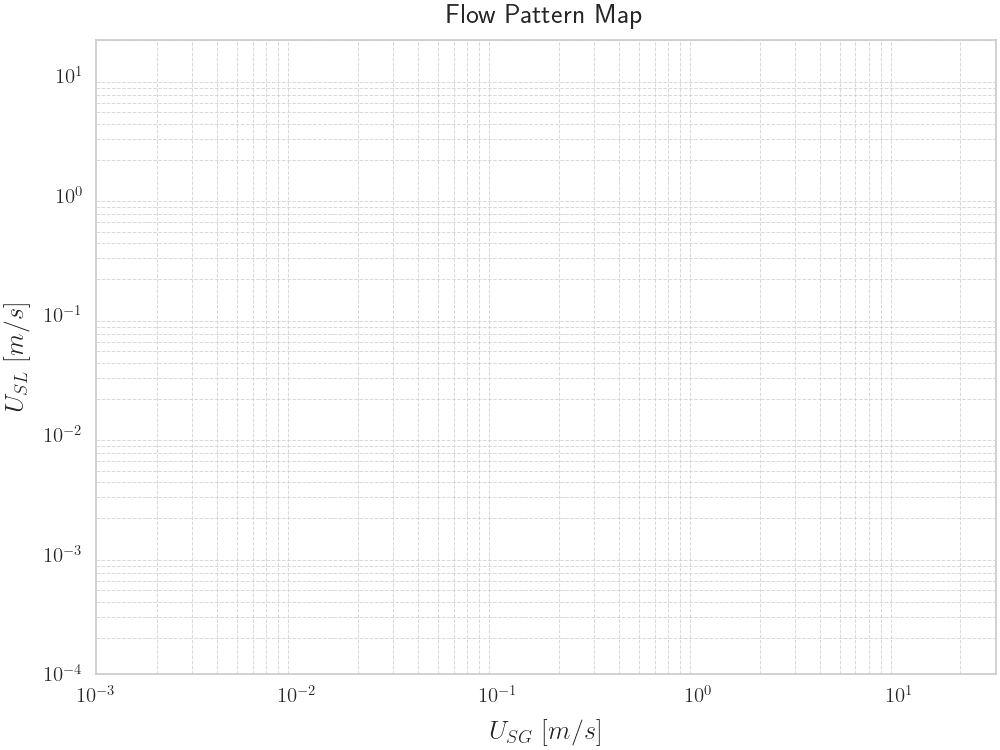

interactive(children=(FloatSlider(value=0.1, description='Gas Superficial Velocity [m/s]', layout=Layout(align…

In [14]:
display(HTML('''<style>
    .widget-label { min-width: 30ex !important; }
</style>'''))

# Global appearance
plt.rcParams['font.family'] = "Times New Roman"
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['text.usetex'] = True

sns.set_theme(
    context="notebook",
    style="whitegrid",
    font_scale=1.12,
    rc={
        "grid.linestyle": "--",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.75,
        "axes.titlesize": 20,
        "axes.labelsize": 19,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "legend.fontsize": 14,
    }
)

# Figure / export settings
DISPLAY_FIGSIZE = (10, 7.5)
SAVE_DPI = 700
BOUNDARY_MARKERSIZE = 4.0
SELECTED_POINT_MARKERSIZE = 9.0
DENSIFY_PER_SEGMENT = 12  # purely for smoother plotting; does not add new model information

fig, ax = plt.subplots(figsize=DISPLAY_FIGSIZE, constrained_layout=True)
ax.set_title('Flow Pattern Map', pad=12)

labels = ['Stratified', 'Annular', 'Wavy', 'Dispersed-Bubble', 'Bubble Flow', 'Flow pattern ID']
colors = ["m", "g", "b", "r", "y", "k"]
markers = ['.', '.', '.', '.', '.', 'o']

ax.grid(which='both')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-4, 20)
ax.set_xlim(1e-3, 30)
ax.set_aspect("auto")   # important: do not use axis('equal')
ax.set_xlabel('$U_{SG}\;[m/s]$', labelpad=10)
ax.set_ylabel('$U_{SL}\;[m/s]$', labelpad=10)
plt.show()

text = None

def densify_curve_loglog(x, y, points_per_segment=DENSIFY_PER_SEGMENT):
    """
    Densify a positive x-y curve in log-log space for smoother-looking
    boundary scatters. This improves the visual refinement only; it does
    not create new FlowPat calculations.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if np.count_nonzero(valid) < 2:
        return x[valid], y[valid]

    dense_x = []
    dense_y = []
    start = None

    for i, ok in enumerate(valid):
        if ok and start is None:
            start = i

        is_segment_end = start is not None and (i == len(valid) - 1 or not valid[i + 1])
        if is_segment_end:
            xs = x[start:i + 1]
            ys = y[start:i + 1]

            if len(xs) == 1:
                dense_x.extend(xs.tolist())
                dense_y.extend(ys.tolist())
            else:
                lx = np.log10(xs)
                ly = np.log10(ys)

                for j in range(len(xs) - 1):
                    t = np.linspace(0.0, 1.0, points_per_segment, endpoint=False)
                    dense_x.extend((10 ** ((1 - t) * lx[j] + t * lx[j + 1])).tolist())
                    dense_y.extend((10 ** ((1 - t) * ly[j] + t * ly[j + 1])).tolist())

                dense_x.append(xs[-1])
                dense_y.append(ys[-1])

            dense_x.append(np.nan)
            dense_y.append(np.nan)
            start = None

    if dense_x and np.isnan(dense_x[-1]):
        dense_x.pop()
        dense_y.pop()

    return np.array(dense_x), np.array(dense_y)

def save_current_figure():
    out_path = create_out_path()
    fig.savefig(
        out_path / "flow_pattern_map_600dpi.png",
        dpi=SAVE_DPI,
        bbox_inches="tight",
        pad_inches=0.08,
        facecolor="white",
    )

def update_plot(x, y, ax, i, markersize):
    lines = ax.lines
    if lines and i < len(lines):
        line = ax.lines[i]
        line.set_xdata(x)
        line.set_ydata(y)
        line.set_markersize(markersize)
    else:
        ax.plot(
            x, y,
            linestyle='None',
            marker=markers[i],
            markersize=markersize,
            color=colors[i],
            label=labels[i],
        )
        ax.legend(loc="best", frameon=True)

@interact(
    us_G=us_G_button, us_L=us_L_button,
    ρ_L=ρ_L_button, ρ_G=ρ_G_button, μ_L=μ_L_button, μ_G=μ_G_button,
    σ=σ_button, D=D_button, θ=θ_button,
    k_s=k_s_button, interface=interface_button,
)
def plot_transition_points(us_G, us_L, ρ_L, ρ_G, μ_L, μ_G, σ, D, θ, k_s, interface):
    transition = calculate_transition_lines(ρ_L, ρ_G, μ_L, μ_G, σ, D, θ, k_s, interface)
    flow_pattern = calculate_flow_pattern(us_L, us_G, ρ_L, ρ_G, μ_L, μ_G, σ, D, θ, k_s)

    n_transitions = 5
    for i in range(n_transitions):
        x_raw = transition[:, 2 * i]
        y_raw = transition[:, 2 * i + 1]
        x, y = densify_curve_loglog(x_raw, y_raw)
        update_plot(x, y, ax, i, BOUNDARY_MARKERSIZE)

    global text
    if text:
        text.remove()
    if flow_pattern is None:
        update_plot([1e-3], [1e-3], ax, n_transitions, SELECTED_POINT_MARKERSIZE)
    else:
        update_plot([us_G], [us_L], ax, n_transitions, SELECTED_POINT_MARKERSIZE)
        short = flow_pattern[0]
        full = flow_pattern[1]
        text = ax.text(
            us_G, us_L,
            f" {short} - {full}",
            fontsize=18,
            ha="left",
            va="bottom",
            clip_on=False,
        )

    fig.canvas.draw_idle()
    save_current_figure()


In [3]:
calculate_flow_pattern(
    us_L=0.070,
    us_G=1.0,
    ρ_L=997.9,
    ρ_G=50,
    μ_L=0.001,
    μ_G=0.0000168,
    σ=0.07,
    D=0.1,
    θ=-2.80,
    k_s=1e-5
)

('SW', 'Stratified Wavy')